In [1]:
import pandas as pd
import numpy as np
import importlib

import plotly.express as px

import irina.utility_functions as uf

In [8]:
start_year = 1970
end_year = 2023
year_list = range(1970, 2023)
mode = "collaborative"

In [9]:
# df_prob_yearly_list = []
#
# for year_loop in year_list:
#     df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year_loop}.csv", index_col=0)
#     df_prob_yearly_list.append(
#         df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop)
#     )
#
# df_prob_yearly = pd.concat(df_prob_yearly_list)

In [38]:
country = "ID"
df_country = (
    pd.read_csv(uf.PATH+f"df_prob_yearly.csv")
    .query("country == @country and mode == @mode")
    .drop(["country", "mode"], axis=1)
    .set_index("year")
)
# df_country

In [39]:
df_dist = uf.get_jaccard_distances(df_country)

In [40]:
uf.plotly_heatmap(df_country, x_labels=df_country.index, y_labels=df_country.columns, z_min=0, z_max=0.05, colorscale="non", line_height=10, title=uf.id2name_country[country])

In [41]:
uf.plotly_heatmap(
    df_dist,
    x_labels=df_dist.columns,
    y_labels=df_dist.index,
    colorscale="non-symmetric",
    line_height=10,
    title=uf.id2name_country[country],
    # z_min=0,
    # z_max=1,
)

In [9]:
# df_dist_yearly_list = []
# for country_loop in df_prob_yearly.country.unique():
#     # print(country_loop)
#     df_country = (
#         df_prob_yearly
#         .query("country == @country_loop")
#         .drop("country", axis=1)
#         .set_index("year")
#     )
#     df_dist = uf.get_jaccard_distances(df_country)
#     df_country_stat = pd.DataFrame({}, index=df_dist.index)
#     df_country_stat["country"] = country_loop
#     df_country_stat["from_start"] = df_dist.iloc[0]
#     df_country_stat["dist_yearly"] = np.concatenate([[np.nan], np.diagonal(df_dist.values, 1)])
#     df_dist_yearly_list.append(df_country_stat.reset_index())
# df_dist_yearly = pd.concat(df_dist_yearly_list)
# df_dist_yearly.to_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode[:-1]}.csv", index=False)
# df_dist_yearly = pd.read_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode[:-1]}.csv")

In [19]:
df_dist_yearly = pd.read_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode}.csv")
rolling_years = 20
df_dist_yearly = (
    df_dist_yearly
    .assign(
        rolling_std=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.rolling(rolling_years, min_periods=1).std().replace(0, np.nan)),
        rolling_std_diff=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.diff().abs()),
        dist_pct_change=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.pct_change(fill_method=None).abs()),
    )
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2")
)
# df_dist_yearly

In [32]:
px.box(
    df_dist_yearly,
    x="year",
    y="dist_yearly",
    title=f"Distance yearly, Jaccard, {mode}",
)

In [21]:
year = [2022, 2000, 1980]
px.histogram(
    df_dist_yearly.query("year == @year"),
    x="dist_pct_change",
    nbins=200,
    color="year",
    barmode="overlay",
    histnorm="probability"
)

In [22]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

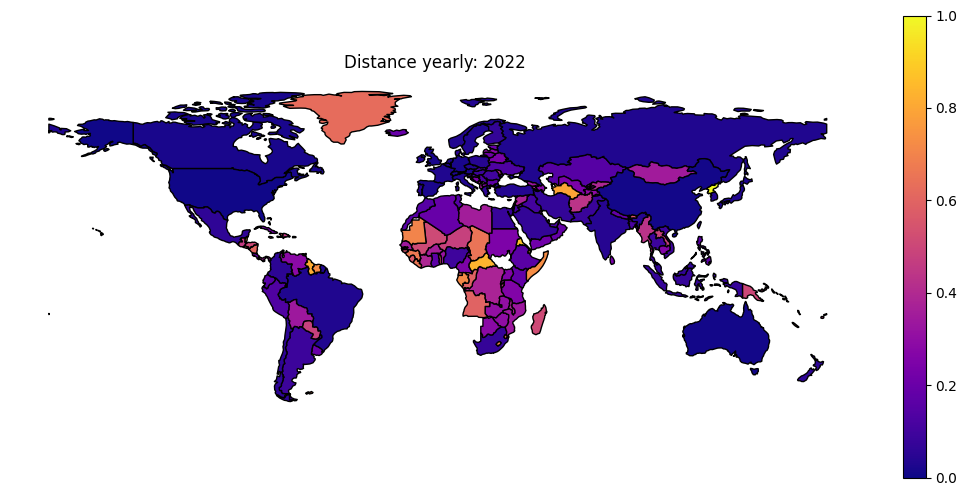

In [23]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"),
                       "dist_yearly", range=(0, 1), title=f"Distance yearly: {year}")


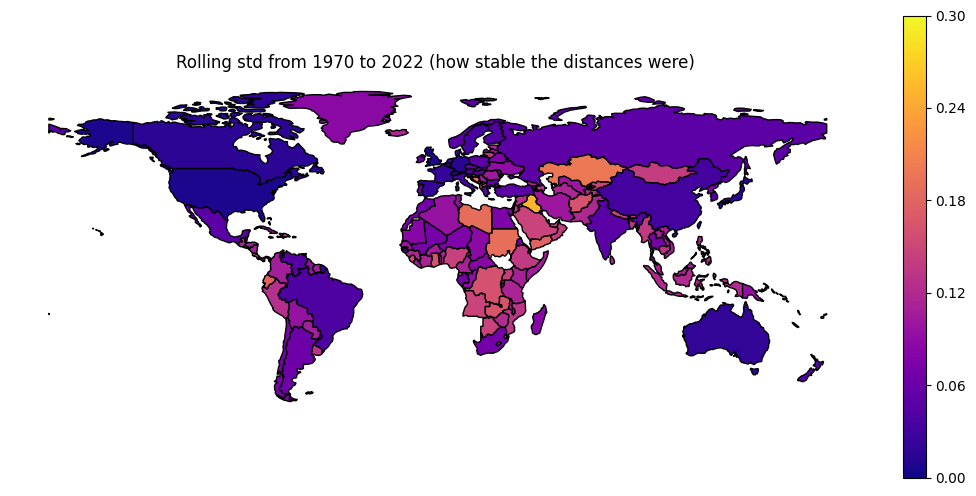

In [24]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"), "rolling_std", range=(0, 0.3),
                       title=f"Rolling std from {start_year} to {year} (how stable the distances were)")

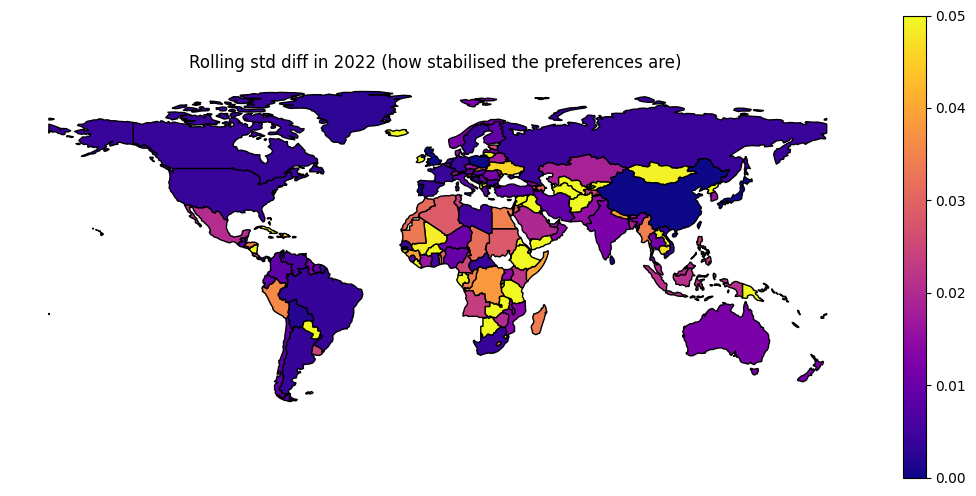

In [25]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"), "rolling_std_diff", range=(0, 0.05),
                       title=f"Rolling std diff in {year} (how stabilised the preferences are)")